In [1]:
%load_ext autoreload
%autoreload 2


In [6]:
import os
from collections import defaultdict
import pandas as pd
import re
from agreement_utils import extract_name, run_2_annotators_agreement, calculate_average_scores
from IPython.core.interactiveshell import InteractiveShell

InteractiveShell.ast_node_interactivity = "all"

In [7]:
def extract_document_number(file_path):
    # Regular expression to match the document number in the file path
    match = re.search(r'/(\d+)_', file_path)
    if match:
        return match.group(1)
    return None


def find_matching_documents(list1, list2):
    # Extract document numbers from both lists
    doc_numbers_list1 = {extract_document_number(file): file for file in list1}
    doc_numbers_list2 = {extract_document_number(file): file for file in list2}

    # Find common document numbers
    common_docs = set(doc_numbers_list1.keys()).intersection(set(doc_numbers_list2.keys()))

    # Return files with matching document numbers from both lists
    matching_files = [(doc_numbers_list1[doc], doc_numbers_list2[doc]) for doc in common_docs]
    return matching_files


In [8]:
def extract_file_couples(annotator_names, conllu_annotated_files_path):
    annotator_files = {}
    for name in annotator_names:
        annotator_files[name] = {f.split("_")[0]: f for f in file_by_annotator[name]}
    print(f"Check agreement for {len(annotator_files)} files")
    file_couples = []
    for i, name1 in enumerate(annotator_names):
        for j, name2 in enumerate(annotator_names[i + 1:], i + 1):

            a1_f = []
            a2_f = []

            for key, a1_file in annotator_files[name1].items():
                if key in annotator_files[name2]:
                    a1_f.append(os.path.join(conllu_annotated_files_path, a1_file))
                    a2_f.append(os.path.join(conllu_annotated_files_path, annotator_files[name2][key]))

            file_couples.append((a1_f, a2_f))
    return file_couples


## Third Round Agreement - Inner Agreement Point-AI

In [10]:
conllu_annotated_files_paths = "../../conllu_out_annotation/"

In [11]:
keep_singletons = False
calc_with_mentions = False
conllu_annotated_dirs = [f for f in os.listdir(conllu_annotated_files_paths) if f.startswith("documents")]
scores = defaultdict(list)
for dir in conllu_annotated_dirs:
    file_by_annotator = defaultdict(list)
    dir_path = os.path.join(conllu_annotated_files_paths, dir)
    for file in os.listdir(dir_path):
        file_by_annotator[extract_name(file)].append(file)
    # print(file_by_annotator.keys())
    # print(file_by_annotator.values())
    file_couples = extract_file_couples(list(file_by_annotator.keys()), dir_path)
    for files_annotator_1, files_annotator_2 in file_couples:
        common = find_matching_documents(files_annotator_1, files_annotator_2)
        for a1_f, a2_f in common:
            try:
                score = calculate_average_scores(run_2_annotators_agreement([a1_f], [a2_f], keep_singletons), False)
            except Exception as e:
                print(f"Error in {a1_f} and {a2_f}")
                print(e)
                continue
            scores[extract_document_number(a1_f)].append(score)

    # print(f"Agreement for {dir}")
    # score = calculate_average_scores(run_2_annotators_agreement(a1_f, a2_f, keep_singletons), False)
    # scores[dir] = score

Check agreement for 3 files
37 and 26 singletons are removed from the key and system files, respectively
mentions   Recall: 92.00  Precision: 63.89  F1: 75.41
muc        Recall: 87.50  Precision: 60.87  F1: 71.79
bcub       Recall: 88.00  Precision: 58.33  F1: 70.16
ceafe      Recall: 80.00  Precision: 55.38  F1: 65.45
lea        Recall: 84.00  Precision: 55.56  F1: 66.88
CoNLL score: 68.57
36 and 35 singletons are removed from the key and system files, respectively
mentions   Recall: 93.55  Precision: 90.62  F1: 92.06
muc        Recall: 85.71  Precision: 81.82  F1: 83.72
bcub       Recall: 85.42  Precision: 81.82  F1: 83.58
ceafe      Recall: 92.47  Precision: 92.47  F1: 92.47
lea        Recall: 81.25  Precision: 77.78  F1: 79.48
CoNLL score: 84.81
48 and 45 singletons are removed from the key and system files, respectively
mentions   Recall: 91.67  Precision: 84.62  F1: 88.00
muc        Recall: 80.00  Precision: 76.92  F1: 78.43
bcub       Recall: 80.32  Precision: 72.82  F1: 76.39
c

In [12]:
scores_sor = dict(sorted(scores.items(), key=lambda item: int(item[0])))

In [13]:
scores = {}
docs_agreement_score = {}
for doc, data in scores_sor.items():
    f1_scores = {
        'bcub': [d['bcub']['f1'] for d in data],
        'ceafe': [d['ceafe']['f1'] for d in data],
        'lea': [d['lea']['f1'] for d in data],
        'muc': [d['muc']['f1'] for d in data]
    }
    df = pd.DataFrame(f1_scores)
    average_f1 = df.mean()
    scores[doc] = average_f1
    docs_agreement_score[doc] = average_f1.mean()

In [ ]:
print(
    f"Agreement score for the ocerall document: {sum((docs_agreement_score.values())) / len(docs_agreement_score) * 100:.2f}")


Agreement score for the ocerall document: 81.08


<Figure size 1200x600 with 0 Axes>

Text(0.5, 0, 'Document Ranges (every 10 docs)')

Text(0, 0.5, 'Average Agreement Score (%)')

Text(0.5, 1.0, 'Coreference Agreement Scores by Document Ranges')

([<matplotlib.axis.XTick at 0x13377c2b0>,
 [Text(0, 0, 'Docs 1-10'),
  Text(1, 0, 'Docs 11-20'),
  Text(2, 0, 'Docs 21-30'),
  Text(3, 0, 'Docs 31-40'),
  Text(4, 0, 'Docs 41-50'),
  Text(5, 0, 'Docs 51-60'),
  Text(6, 0, 'Docs 61-70'),
  Text(7, 0, 'Docs 71-80'),
  Text(8, 0, 'Docs 81-90'),
  Text(9, 0, 'Docs 91-100'),
  Text(10, 0, 'Docs 101-110'),
  Text(11, 0, 'Docs 111-120'),
  Text(12, 0, 'Docs 121-130'),
  Text(13, 0, 'Docs 131-140'),
  Text(14, 0, 'Docs 141-150'),
  Text(15, 0, 'Docs 151-160'),
  Text(16, 0, 'Docs 161-170'),
  Text(17, 0, 'Docs 171-180'),
  Text(18, 0, 'Docs 181-190'),
  Text(19, 0, 'Docs 191-200'),
  Text(20, 0, 'Docs 201-210'),
  Text(21, 0, 'Docs 211-220'),
  Text(22, 0, 'Docs 221-233'),
  Text(23, 0, 'Docs 234-243'),
  Text(24, 0, 'Docs 244-253'),
  Text(25, 0, 'Docs 255-264'),
  Text(26, 0, 'Docs 265-274'),
  Text(27, 0, 'Docs 275-284'),
  Text(28, 0, 'Docs 285-294'),
  Text(29, 0, 'Docs 295-304'),
  Text(30, 0, 'Docs 305-314'),
  Text(31, 0, 'Docs 315-326

...

Text(30.0, 77.60026251098137, '77.1%')

Text(31.0, 80.94245473935032, '80.4%')

Text(32.0, 85.16151299842707, '84.7%')

Text(33.0, 84.26507304576255, '83.8%')

Text(34.0, 80.67541956399387, '80.2%')

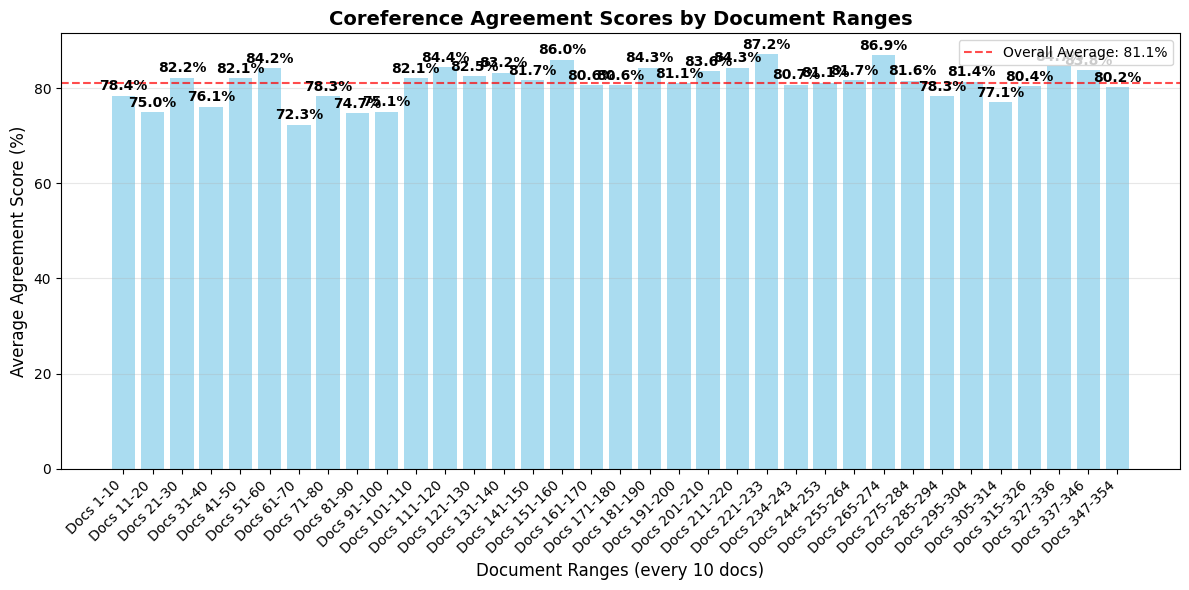

Number of document ranges: 35
Overall average agreement: 81.08%
Range of agreement scores: 72.3% - 87.2%


In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Convert document numbers to integers for proper sorting
doc_numbers = [int(doc) for doc in docs_agreement_score.keys()]
agreement_scores = [docs_agreement_score[str(doc)] * 100 for doc in doc_numbers]

# Sort by document number
sorted_indices = np.argsort(doc_numbers)
sorted_docs = [doc_numbers[i] for i in sorted_indices]
sorted_scores = [agreement_scores[i] for i in sorted_indices]

# Create bins of 10 documents each
bin_size = 10
doc_bins = []
score_bins = []

for i in range(0, len(sorted_docs), bin_size):
    bin_docs = sorted_docs[i:i + bin_size]
    bin_scores = sorted_scores[i:i + bin_size]

    if bin_scores:  # Only add if there are scores in this bin
        doc_bins.append(f"Docs {bin_docs[0]}-{bin_docs[-1]}")
        score_bins.append(np.mean(bin_scores))

# Create the plot
plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(doc_bins)), score_bins, color='skyblue', alpha=0.7)

# Customize the plot
plt.xlabel('Document Ranges (every 10 docs)', fontsize=12)
plt.ylabel('Average Agreement Score (%)', fontsize=12)
plt.title('Coreference Agreement Scores by Document Ranges', fontsize=14, fontweight='bold')
plt.xticks(range(len(doc_bins)), doc_bins, rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, score) in enumerate(zip(bars, score_bins)):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{score:.1f}%', ha='center', va='bottom', fontweight='bold')

# Add overall average line
overall_avg = np.mean(score_bins)
plt.axhline(y=overall_avg, color='red', linestyle='--', alpha=0.7,
            label=f'Overall Average: {overall_avg:.1f}%')
plt.legend()

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Number of document ranges: {len(doc_bins)}")
print(f"Overall average agreement: {overall_avg:.2f}%")
print(f"Range of agreement scores: {min(score_bins):.1f}% - {max(score_bins):.1f}%")